In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("retail_sales_dataset.csv")


df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [38]:
print("Shape of Dataset:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape of Dataset: (1000, 9)

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0


The dataset contains transaction records with no major missing values or duplicate records. The data is ready for analysis.

In [39]:
print(df.describe())

print("\nMean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nStandard Deviation")
print(df.std(numeric_only=True))

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
Transac

The dataset provides information on customer age, quantity purchased, price per unit, and total transaction amount.

In [40]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

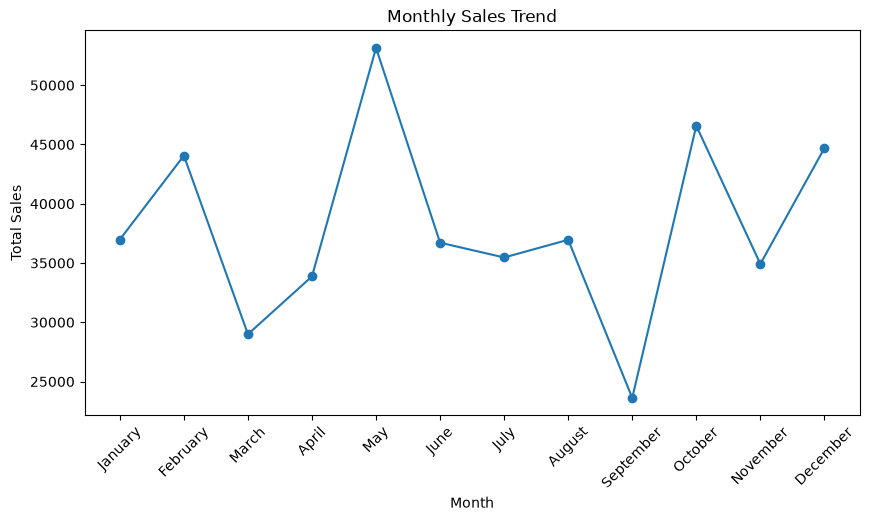

In [41]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

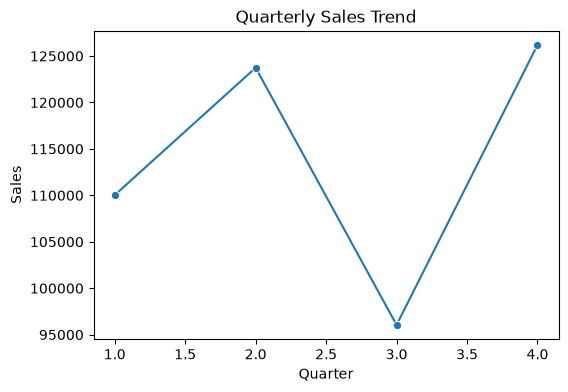

In [42]:
quarter_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(6,4))
sns.lineplot(x=quarter_sales.index, y=quarter_sales.values, marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

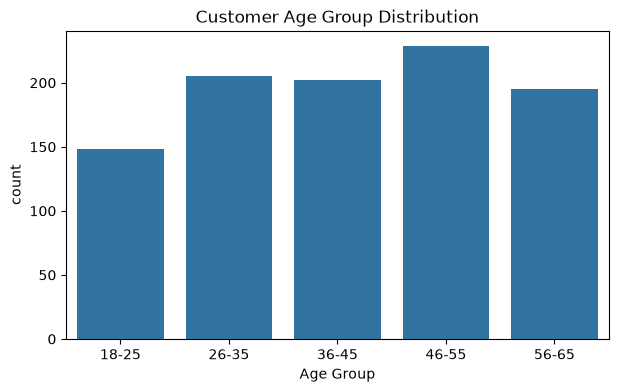

In [43]:
bins = [18,25,35,45,55,65]
labels = ["18-25","26-35","36-45","46-55","56-65"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Age Group")
plt.title("Customer Age Group Distribution")
plt.show()

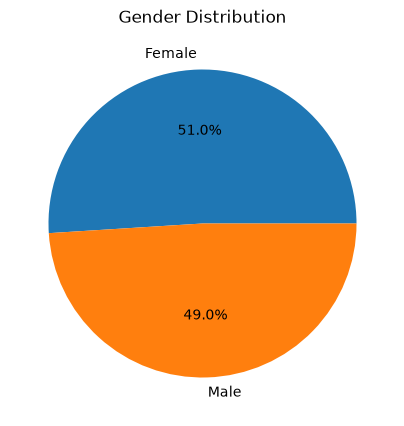

In [44]:
plt.figure(figsize=(5,5))
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

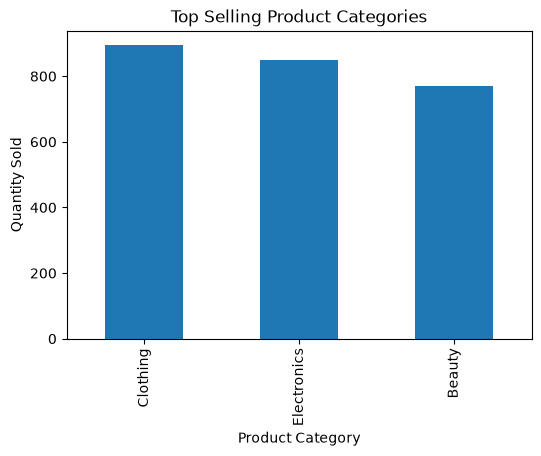

In [45]:
top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
top_products.plot(kind="bar")
plt.title("Top Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.show()

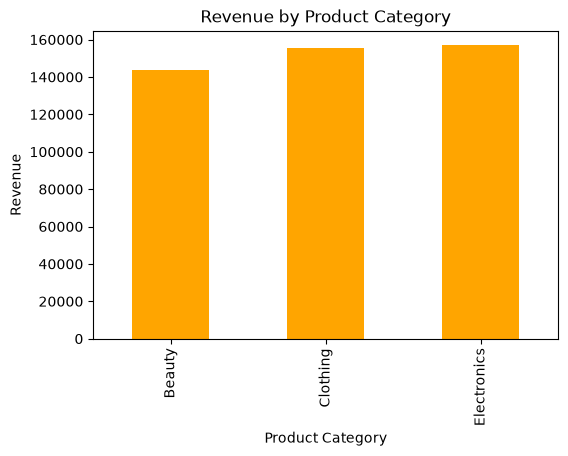

In [46]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(6,4))
category_sales.plot(kind="bar", color="orange")
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

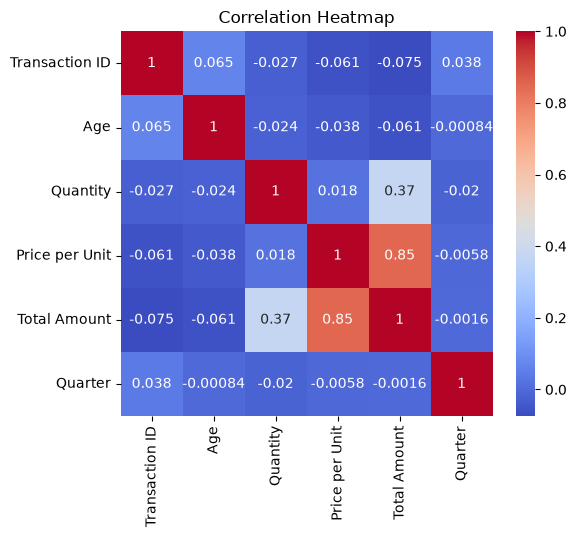

In [47]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Business Recommendations
1.Increase inventory and marketing for the highest-selling product category.
2.Launch targeted promotions during months with lower sales to improve revenue.
3.Create personalized offers for the most active customer age groups to increase customer retention.

Note: This dataset contains Product Category instead of individual product names. Therefore, the analysis has been performed on the top-selling product categories.

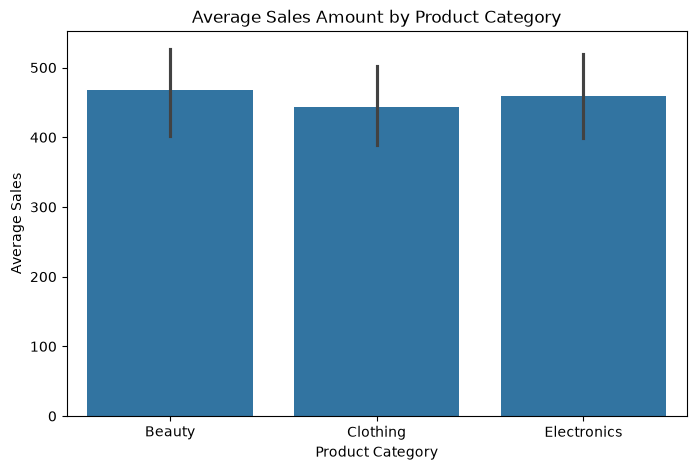

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Product Category",
    y="Total Amount",
    estimator="mean"
)

plt.title("Average Sales Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Sales")

plt.show()

Electronics have the highest average transaction value, while Beauty and Clothing have lower average purchase values. This indicates customers spend more per purchase on Electronics.

# Conclusion

The exploratory data analysis provided valuable insights into customer purchasing behaviour and retail sales performance.

### Business Recommendations

1. Increase inventory for the best-performing product categories to maximize revenue.

2. Introduce promotional offers during months with lower sales to improve overall revenue.

3. Design targeted marketing campaigns for the most active customer age groups.

4. Use customer purchasing patterns to recommend relevant products and improve customer satisfaction.

In [49]:
plt.savefig("screenshots/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

quarterly_sales.png
gender_distribution.png
age_groups.png
revenue_by_category.png
correlation_heatmap.png
average_sales_by_category.png

In [50]:
plt.savefig("screenshots/average_sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>